In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

# ==============================
# 1. Load data
# ==============================
df = pd.read_csv("data.csv")

df = df.rename(columns={
    "Annual Income (k$)": "Income",
    "Spending Score (1-100)": "Score"
})

X = df[["Income", "Score"]]

# ==============================
# 2. Scale the data
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 3. PCA (2D)
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ==============================
# 4. DBSCAN Clustering
# ==============================
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_pca)     # -1 means noise/outlier

# ==============================
# 5. Isolation Forest Anomaly Detection
# ==============================
iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_flag = iso.fit_predict(X_scaled)       # 1 = normal, -1 = anomaly
anomaly_score = -iso.decision_function(X_scaled)  # higher = more anomalous

# ==============================
# 6. Build Output DataFrame
# ==============================
output = pd.DataFrame({
    "CustomerID": df["CustomerID"],
    "Income": df["Income"],
    "Score": df["Score"],
    "cluster": labels,
    "anomaly_flag": anomaly_flag,
    "anomaly_score": anomaly_score
})

output.head()


,CustomerID,Income,Score,cluster,anomaly_flag,anomaly_score
0,1,15,39,0,1,-0.013286
1,2,15,81,0,1,-0.018421
2,3,16,6,0,1,-0.007585
3,4,16,77,0,1,-0.063614
4,5,17,40,0,1,-0.053019


In [3]:
output

,CustomerID,Income,Score,cluster,anomaly_flag,anomaly_score
0,1,15,39,0,1,-0.013286
1,2,15,81,0,1,-0.018421
2,3,16,6,0,1,-0.007585
3,4,16,77,0,1,-0.063614
4,5,17,40,0,1,-0.053019
...,...,...,...,...,...,...
195,196,120,79,-1,-1,0.011208
196,197,126,28,-1,-1,0.032277
197,198,126,74,-1,-1,0.020334
198,199,137,18,-1,-1,0.065849


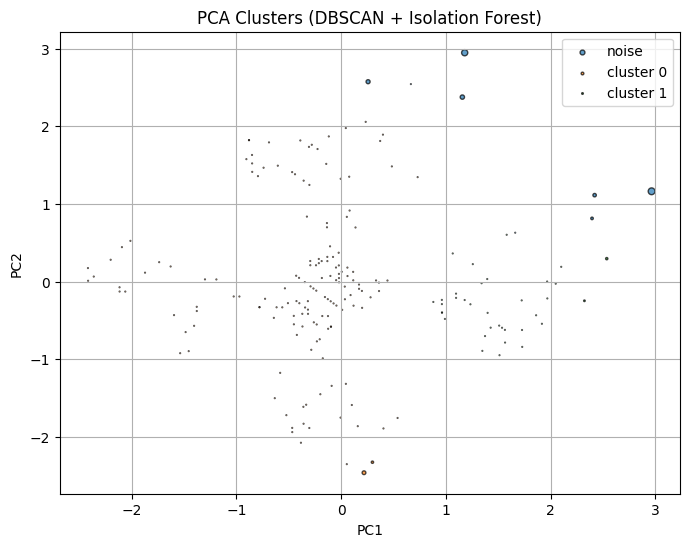

In [5]:
import matplotlib.pyplot as plt
import numpy as np

pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# Make sure anomaly_score is positive
safe_scores = np.clip(anomaly_score, 0.001, None)  # avoid zeros & negatives
sizes = safe_scores * 300   # scale bubbles

plt.figure(figsize=(8,6))

unique_labels = sorted(set(labels))

for lbl in unique_labels:
    mask = labels == lbl

    # Skip clusters with zero points
    if mask.sum() == 0:
        continue

    lbl_name = "noise" if lbl == -1 else f"cluster {lbl}"

    plt.scatter(
        pc1[mask],
        pc2[mask],
        label=lbl_name,
        s=sizes[mask],
        alpha=0.7,
        edgecolors='k'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clusters (DBSCAN + Isolation Forest)")
plt.legend()
plt.grid(True)
plt.show()



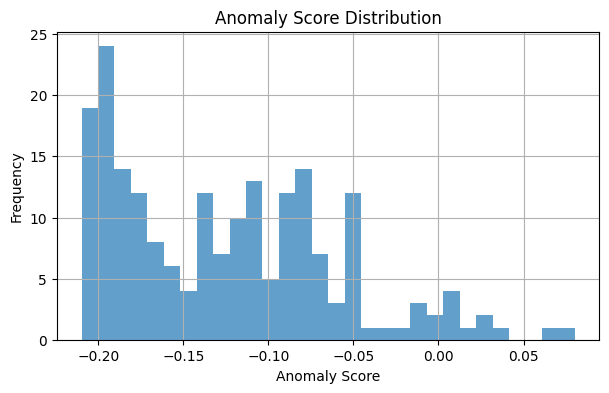

In [6]:
plt.figure(figsize=(7,4))
plt.hist(anomaly_score, bins=30, alpha=0.7)
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [7]:
output.groupby("cluster")[["Income", "Score"]].agg(["mean", "std", "min", "max"])


Income                           Score                   
               mean        std  min  max       mean        std min max
cluster                                                               
-1       122.750000  11.510864  103  137  46.875000  32.108911   8  83
 0        52.490446  21.811141   15  103  43.101911  22.249225   1  99
 1        82.542857  10.925800   69  113  82.800000   9.498607  63  97

In [8]:
output[output["anomaly_flag"] == -1].head(10)


,CustomerID,Income,Score,cluster,anomaly_flag,anomaly_score
11,12,19,99,0,-1,0.024102
19,20,23,98,0,-1,0.009253
185,186,99,97,1,-1,0.004320
192,193,113,8,-1,-1,0.028330
193,194,113,91,1,-1,0.008827
195,196,120,79,-1,-1,0.011208
196,197,126,28,-1,-1,0.032277
197,198,126,74,-1,-1,0.020334
198,199,137,18,-1,-1,0.065849
199,200,137,83,-1,-1,0.080127
